# Issues
- For vertical levels, sigma-level approximation is used instead of the true hybrid level coordinate system. Pressure levels defined by sigma values are calculated as$$p_{\text{level}} = \sigma_{\text{level}} * p_{\text{surface}}$$ and these $\sigma_{\text{level}}$ are retrieved from [this FAQ page](https://rapidrefresh.noaa.gov/faq/HRRR.faq.html). However, I suspect that this source is outdated as StormCast documentation refers to HRRR's vertical coordinate system as **hybrid** levels and section 2.1 of [this documentation](https://opensky.ucar.edu/islandora/object/technotes%3A576) of Advanced Research WRF model v4 describes a hybrid level system that I suspect HRRR v4 (the latest version) also uses. Anyway I couldn't find a source for the parameters corresponding to each level in the hybrid system so the sigma levels are used as a first attempt approximation.

- HRRR uses Lambert Conformal Grid. However my conversion from ERA5's lat/lon grid to HRRR-format input just bilinearly interpolates the ERA5 grid (something like a spherical coordinate grid) to the required resolution. Again, suitable for a first approximation.

- Composite reflectivity, `refc`, is one of HRRR's 99 variables but does not exist in ERA5. Set to zero everywhere initial conditions for now.

- Some functions are designed to handle multiple initialisation times while others are designed to only handle one (ie assumes that `len(times)==1`). Just stick to one initialisation time for now – I don't quite get the purpose of multiple initialisation times yet.

In [ ]:
# ── 0. Install & imports ──────────────────────────────────────────────────────

!pip install -q earth2studio[stormcast]

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import earth2studio.run as run

import utils as ut
import importlib
importlib.reload(ut)

from earth2studio.models.px import StormCast
from earth2studio.data import GFS_FX
from earth2studio.io import ZarrBackend

# ── 1. Configuration ──────────────────────────────────────────────────────────

# File paths
PATH_SURFACE    = "/content/surface_variables.nc"
PATH_PRESSURE   = "/content/pressure_level_variables.nc"
PATH_SP         = "/content/surface_pressure.nc"
PATH_REFC       = "/content/tcrw.nc"
PATH_OUTPUT     = "stormcast_output_era5.zarr"

# ── 2. Model & coordinate setup ───────────────────────────────────────────────

package = StormCast.load_default_package()
model   = StormCast.load_model(package, conditioning_data_source=GFS_FX())

coords    = model.input_coords()
VARIABLES = list(coords["variable"])
HRRR_Y    = np.asarray(coords["hrrr_y"])
HRRR_X    = np.asarray(coords["hrrr_x"])
NY, NX    = len(HRRR_Y), len(HRRR_X)

# —— 3. Helper functions to build input/truth arrays ———————————————————————————

def _put_field(data, var_name, field, time_value=None):
    """
    Put a 2D field into either:
    - input array: (time, variable, hrrr_y, hrrr_x)
    - truth array: (variable, hrrr_y, hrrr_x)
    """
    if "time" in data.dims:
        if time_value is None:
            raise ValueError("time_value is required for data with a time dimension.")
        data.loc[dict(time=time_value, variable=var_name)] = field
    else:
        data.loc[dict(variable=var_name)] = field


def fill_surface_fields(
    data,
    ds_surface,
    src_lats,
    src_lons,
    target_lats,
    target_lons,
    time_index=0,
    time_value=None,
    verbose=False,
):
    """Fill t2m, u10m, v10m, mslp."""

    available_vars = set(data["variable"].values)

    for era5_name, sc_name in ut.ERA5_SURFACE_MAP.items():
        if sc_name not in available_vars:
            continue

        raw = ds_surface[era5_name].isel(valid_time=time_index).values.astype(np.float32)

        field = ut.hinterp(
            raw,
            src_lats,
            src_lons,
            target_lats,
            target_lons,
        )

        ut.assert_no_nan(sc_name, field)
        _put_field(data, sc_name, field, time_value=time_value)

        if verbose:
            print(
                f"  {era5_name:4s} → {sc_name:5s} | "
                f"min={field.min():.2f}  max={field.max():.2f}"
            )


def get_surface_pressure(
    ds_surface,
    src_lats,
    src_lons,
    target_lats,
    target_lons,
    time_index=0,
    verbose=False,
):
    """Return surface pressure regridded to the StormCast grid."""

    sp_raw = ds_surface["sp"].isel(valid_time=time_index).values.astype(np.float32)

    sp = ut.hinterp(
        sp_raw,
        src_lats,
        src_lons,
        target_lats,
        target_lons,
    )

    ut.assert_no_nan("sp", sp)

    if verbose:
        print(
            f"\n  sp          | min={sp.min():.1f}  "
            f"max={sp.max():.1f}  mean={sp.mean():.1f} Pa"
        )

    return sp


def fill_hybrid_fields(
    data,
    ds_pressure,
    sp,
    src_lats,
    src_lons,
    target_lats,
    target_lons,
    time_index=0,
    time_value=None,
    verbose=False,
):
    """
    Fill hybrid-level variables:
    u#hl, v#hl, t#hl, q#hl, Z#hl, p#hl.
    """

    era5_p_pa = ds_pressure.pressure_level.values.astype(np.float32) * 100.0
    available_vars = set(data["variable"].values)

    if verbose:
        print("\nRegridding ERA5 pressure-level variables...")

    pressure_3d = {}

    for era5_name in ut.ERA5_PRESSURE_MAP:
        pressure_3d[era5_name] = ut.hinterp_all_levels(
            ds_pressure[era5_name],
            src_lats,
            src_lons,
            target_lats,
            target_lons,
            time_index=time_index,
        )

        if verbose:
            print(f"  {era5_name} pressure levels regridded")

    for level, sigma in ut.HRRR_SIGMA.items():
        p_target = (sigma * sp).astype(np.float32)

        p_name = f"p{level}hl"
        if p_name in available_vars:
            _put_field(data, p_name, p_target, time_value=time_value)

        for era5_name, sc_prefix in ut.ERA5_PRESSURE_MAP.items():
            sc_name = f"{sc_prefix}{level}hl"

            if sc_name not in available_vars:
                continue

            field = ut.vinterp(
                pressure_3d[era5_name],
                era5_p_pa,
                p_target,
            )

            if era5_name == "z":
                field = field / 9.80665

            ut.assert_no_nan(sc_name, field)
            _put_field(data, sc_name, field.astype(np.float32), time_value=time_value)


def fill_refc(
    data,
    ds_surface,
    src_lats,
    src_lons,
    target_lats,
    target_lons,
    time_index=0,
    time_value=None,
):
    """Fill refc using ERA5 tcrw proxy."""

    available_vars = set(data["variable"].values)

    if "refc" not in available_vars:
        return

    if "tcrw" not in ds_surface:
        return

    tcrw_raw = ds_surface["tcrw"].isel(valid_time=time_index).values.astype(np.float32)

    tcrw = ut.hinterp(
        tcrw_raw,
        src_lats,
        src_lons,
        target_lats,
        target_lons,
    )

    ut.assert_no_nan("tcrw", tcrw)

    refc = ut.era5_tcrw_to_refc(
        tcrw=tcrw,
        alpha=10.0,
        tcrw_threshold=0.2,
        min_dbz=-10.0,
        max_dbz=75.0,
    )

    _put_field(data, "refc", refc, time_value=time_value)

def build_input_array():
    """
    Construct the full StormCast input array:
        (time, variable, hrrr_y, hrrr_x) = (1, 99, NY, NX)
    """

    ds_surface = xr.open_dataset(PATH_SURFACE)
    ds_pressure = xr.open_dataset(PATH_PRESSURE)

    ut.validate_era5_datasets(ds_surface, ds_pressure)

    start_time = np.datetime64(ds_surface.valid_time.values[0], "ns")

    src_lats = ds_surface.latitude.values
    src_lons = ds_surface.longitude.values

    target_lats = np.linspace(src_lats.max(), src_lats.min(), NY)
    target_lons = np.linspace(src_lons.min(), src_lons.max(), NX)

    data = xr.DataArray(
        np.zeros((1, len(VARIABLES), NY, NX), dtype=np.float32),
        dims=["time", "variable", "hrrr_y", "hrrr_x"],
        coords={
            "time": [start_time],
            "variable": VARIABLES,
            "hrrr_y": HRRR_Y,
            "hrrr_x": HRRR_X,
        },
    )

    fill_surface_fields(
        data,
        ds_surface,
        src_lats,
        src_lons,
        target_lats,
        target_lons,
        time_index=0,
        time_value=start_time,
        verbose=True,
    )

    sp = get_surface_pressure(
        ds_surface,
        src_lats,
        src_lons,
        target_lats,
        target_lons,
        time_index=0,
        verbose=True,
    )

    fill_hybrid_fields(
        data,
        ds_pressure,
        sp,
        src_lats,
        src_lons,
        target_lats,
        target_lons,
        time_index=0,
        time_value=start_time,
        verbose=True,
    )

    fill_refc(
        data,
        ds_surface,
        src_lats,
        src_lons,
        target_lats,
        target_lons,
        time_index=0,
        time_value=start_time,
    )

    return data, target_lats, target_lons, start_time

def build_era5_truth(
    valid_time,
    variables=VARIABLES,
    hrrr_y=HRRR_Y,
    hrrr_x=HRRR_X,
    ny=NY,
    nx=NX,
    path_surface=PATH_SURFACE,
    path_pressure=PATH_PRESSURE,
):
    """
    Build ERA5 truth in StormCast-style format:
        (variable, hrrr_y, hrrr_x)
    """

    ds_surface = xr.open_dataset(path_surface)
    ds_pressure = xr.open_dataset(path_pressure)

    ut.validate_era5_datasets(ds_surface, ds_pressure)

    valid_time = np.datetime64(valid_time, "ns")
    available_times = ds_surface.valid_time.values.astype("datetime64[ns]")

    if valid_time not in available_times:
        raise ValueError(
            f"{valid_time} not found in ERA5 file. "
            f"Available range: {available_times[0]} to {available_times[-1]}"
        )

    time_index = int(np.where(available_times == valid_time)[0][0])

    src_lats = ds_surface.latitude.values
    src_lons = ds_surface.longitude.values

    target_lats = np.linspace(src_lats.max(), src_lats.min(), ny)
    target_lons = np.linspace(src_lons.min(), src_lons.max(), nx)

    truth = xr.DataArray(
        np.zeros((len(variables), ny, nx), dtype=np.float32),
        dims=["variable", "hrrr_y", "hrrr_x"],
        coords={
            "variable": variables,
            "hrrr_y": hrrr_y,
            "hrrr_x": hrrr_x,
        },
    )

    fill_surface_fields(
        truth,
        ds_surface,
        src_lats,
        src_lons,
        target_lats,
        target_lons,
        time_index=time_index,
        time_value=None,
        verbose=False,
    )

    sp = get_surface_pressure(
        ds_surface,
        src_lats,
        src_lons,
        target_lats,
        target_lons,
        time_index=time_index,
        verbose=False,
    )

    fill_hybrid_fields(
        truth,
        ds_pressure,
        sp,
        src_lats,
        src_lons,
        target_lats,
        target_lons,
        time_index=time_index,
        time_value=None,
        verbose=False,
    )

    fill_refc(
        truth,
        ds_surface,
        src_lats,
        src_lons,
        target_lats,
        target_lons,
        time_index=time_index,
        time_value=None,
    )

    return truth

In [ ]:
# ── 4. Build input array ──────────────────────────────────────────────────────

print("Building input array...")
data, target_lats, target_lons, STARTING_TIME = build_input_array()

is_filled = (data != 0).any(dim=("time", "hrrr_y", "hrrr_x"))

filled = list(data["variable"].values[is_filled.values])
missing = list(data["variable"].values[~is_filled.values])

print(f"\nFilled {len(filled)}/99 variables ({missing} left as zero)")

# ── 5. Wrap and sanity-check ──────────────────────────────────────────────────

my_data = ut.MyLocalData(data)

sample = my_data([STARTING_TIME], VARIABLES)

assert sample.dims == ("time", "variable", "hrrr_y", "hrrr_x")
assert sample.shape == (1, 99, NY, NX)

print(f"Input array verified: {sample.dims} {sample.shape}")

Building input array...
  t2m  → t2m   | min=286.16  max=301.59
  u10  → u10m  | min=-12.06  max=9.37
  v10  → v10m  | min=-13.32  max=5.85
  msl  → mslp  | min=100848.52  max=101975.40

  sp          | min=82826.5  max=102211.7  mean=100273.1 Pa

Regridding ERA5 pressure-level variables...
  u pressure levels regridded
  v pressure levels regridded
  t pressure levels regridded
  q pressure levels regridded
  z pressure levels regridded

Filled 99/99 variables ([] left as zero)
Input array verified: ('time', 'variable', 'hrrr_y', 'hrrr_x') (1, 99, 512, 640)


In [ ]:
# ── 6. Inference ──────────────────────────────────────────────────────────────

io = ZarrBackend(PATH_OUTPUT, backend_kwargs={"overwrite": True})
io = run.deterministic(time=[STARTING_TIME], nsteps=2, prognostic=model, data=my_data, io=io)

2026-06-05 08:16:59.881 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-06-05 08:16:59.882 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda
2026-06-05 08:17:00.514 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from MyLocalData
2026-06-05 08:17:00.851 | INFO     | earth2studio.run:deterministic:139 - Inference starting!



Running inference:   0%|          | 0/3 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Running inference:  33%|███▎      | 1/3 [00:06<00:11,  5.86s/it]

2026-06-05 08:17:06.912 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f000 392543500-971269
2026-06-05 08:17:06.986 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f000 257096274-913862
2026-06-05 08:17:07.071 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f000 258010136-921080



Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Running inference:  33%|███▎      | 1/3 [00:06<00:11,  5.86s/it]

2026-06-05 08:17:07.169 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f000 387534311-863351
2026-06-05 08:17:07.247 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f000 389431998-1237116
2026-06-05 08:17:07.322 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f000 200540265-1166428


...

2026-06-05 08:18:20.576 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f001 415790570-970100
2026-06-05 08:18:20.620 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f001 198310783-723146
2026-06-05 08:18:20.662 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f001 392609487-970808
2026-06-05 08:18:20.713 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f001 201019465-1166929
2026-06-05 08:18:20.760 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f001 251181143-802915



Fetching GFS data: 100%|██████████| 26/26 [00:01<00:00, 21.04it/s]


2026-06-05 08:18:20.815 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/18/atmos/gfs.t18z.pgrb2.0p25.f001 253939286-1258205



Running inference: 100%|██████████| 3/3 [02:29<00:00, 49.72s/it]

2026-06-05 08:19:30.032 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete


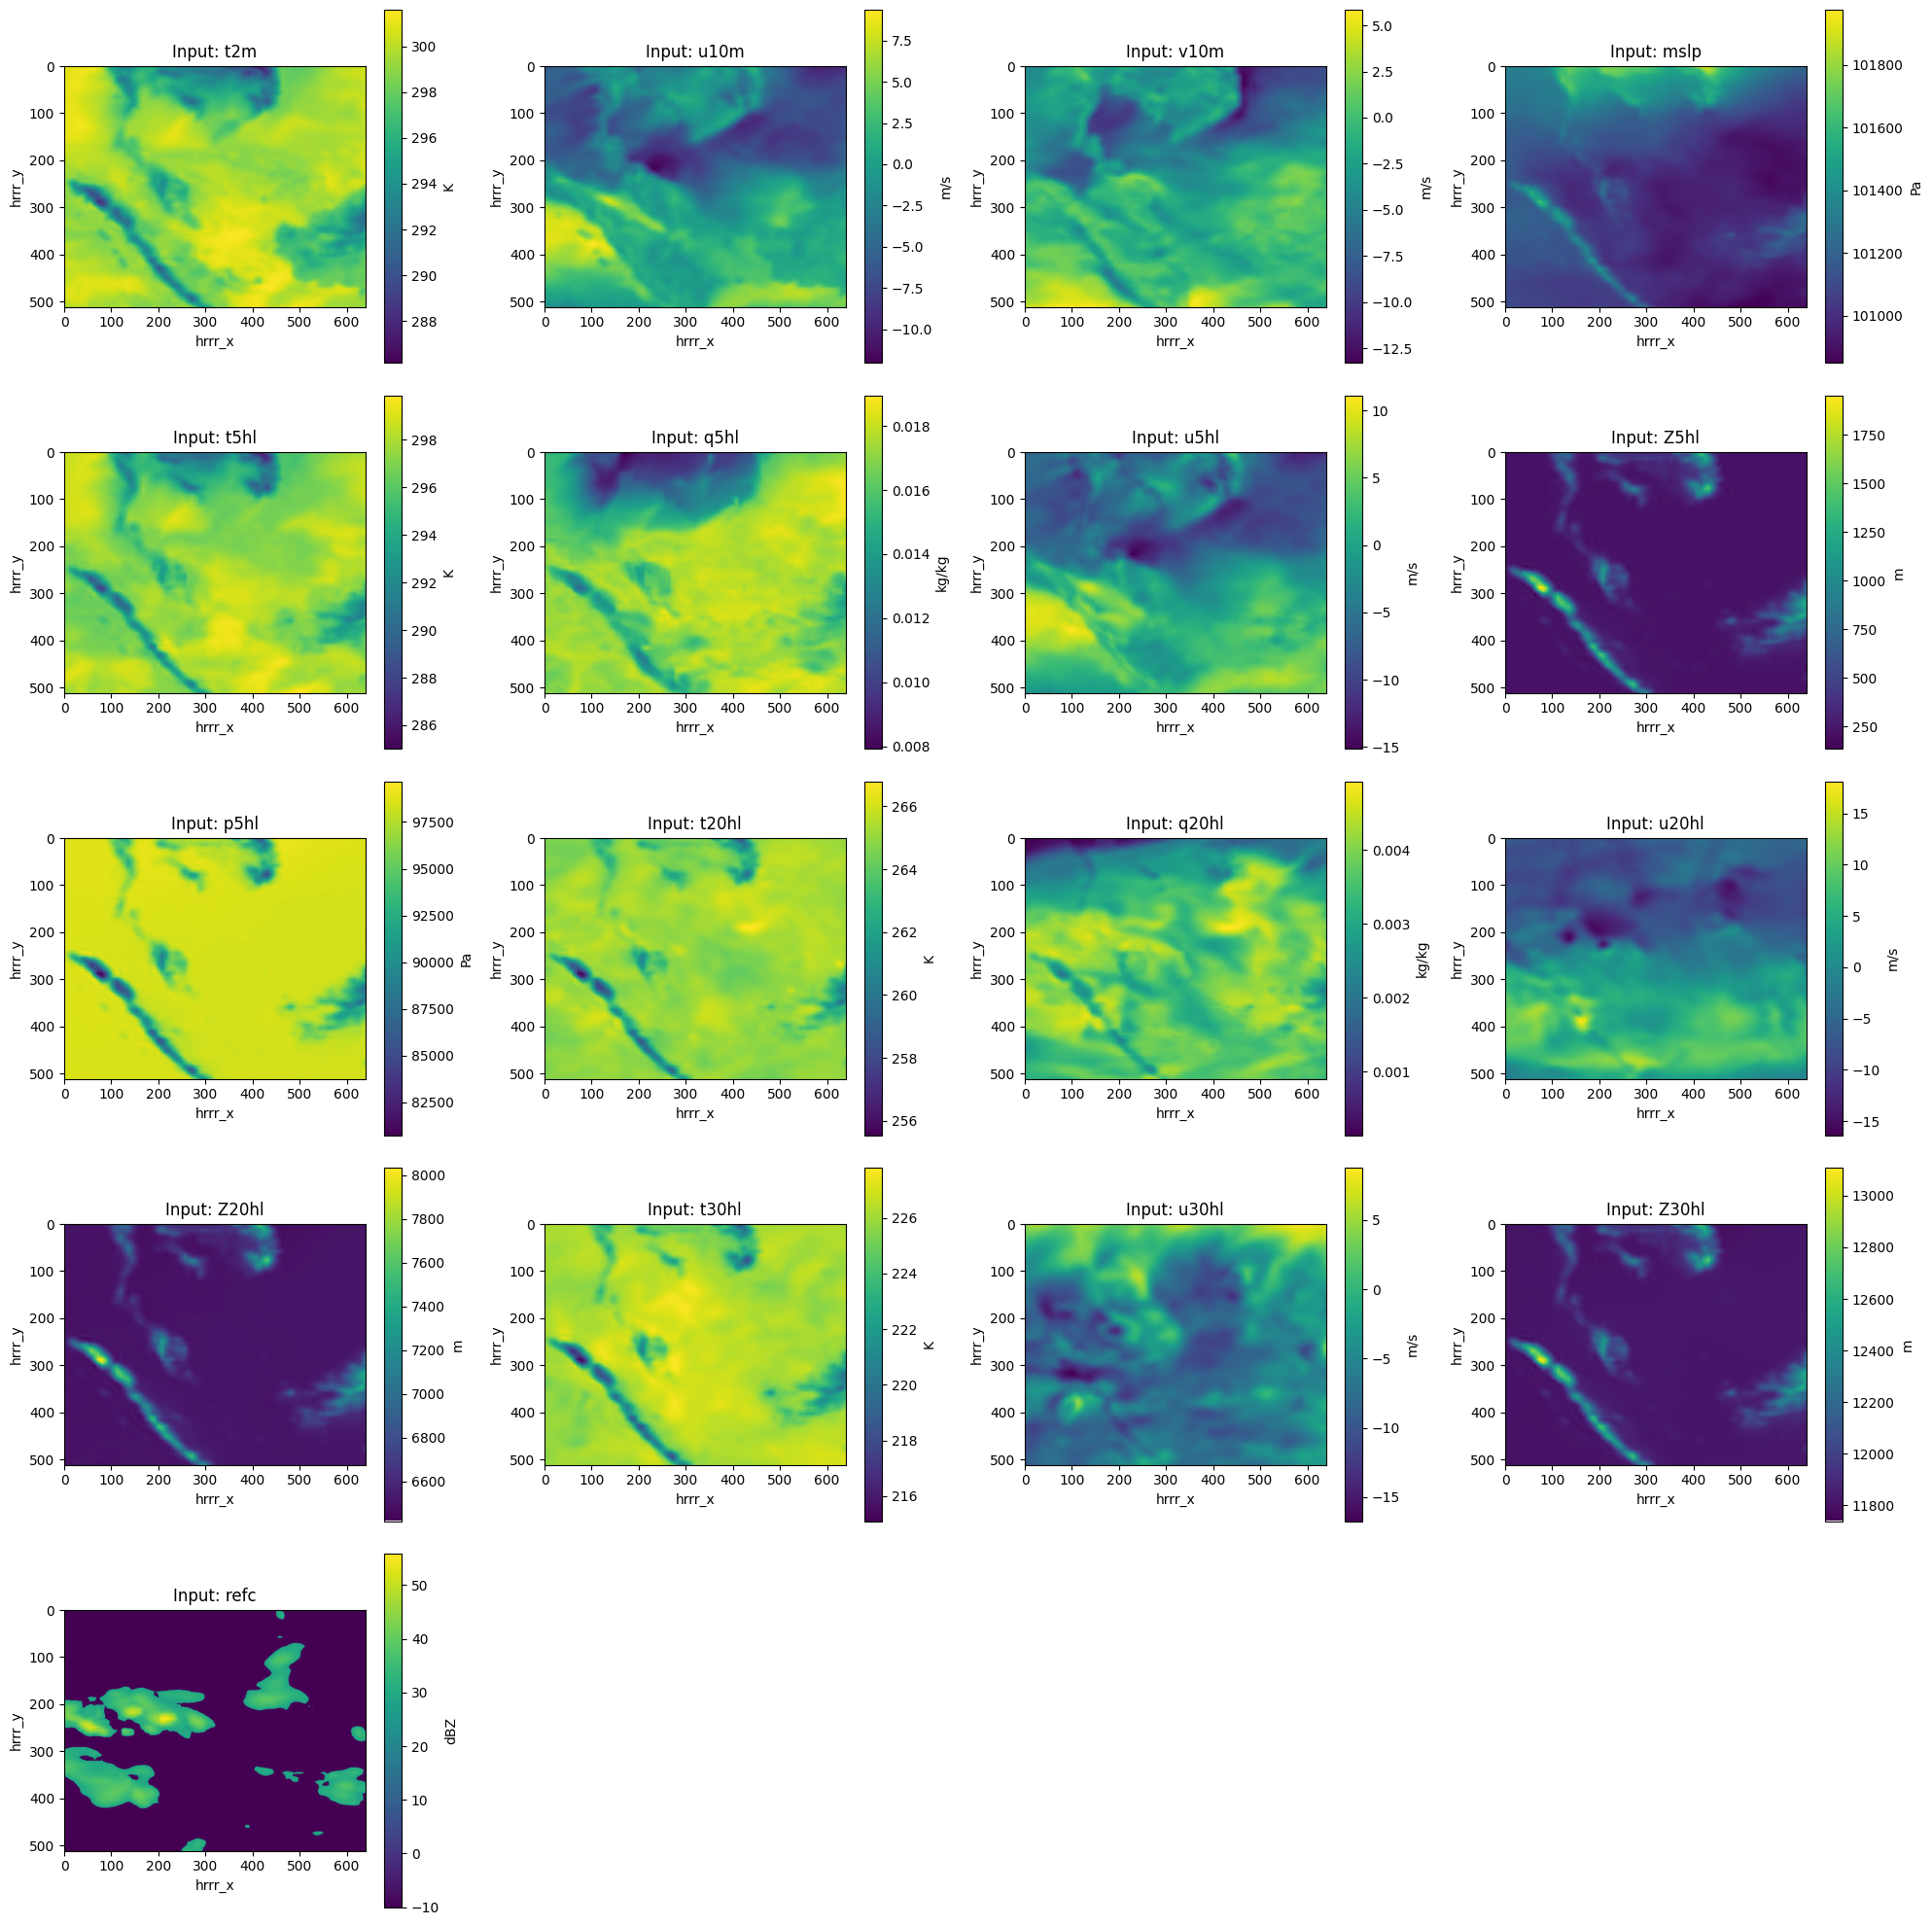

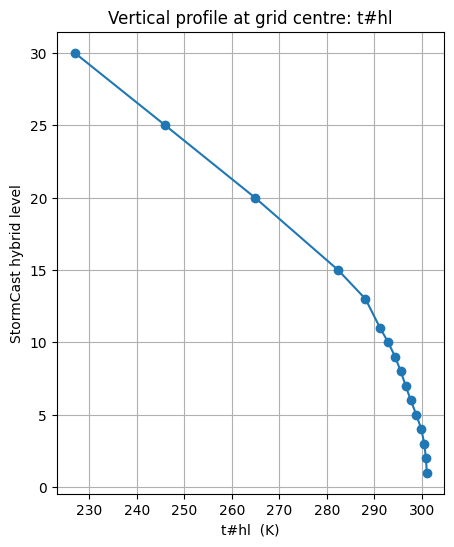

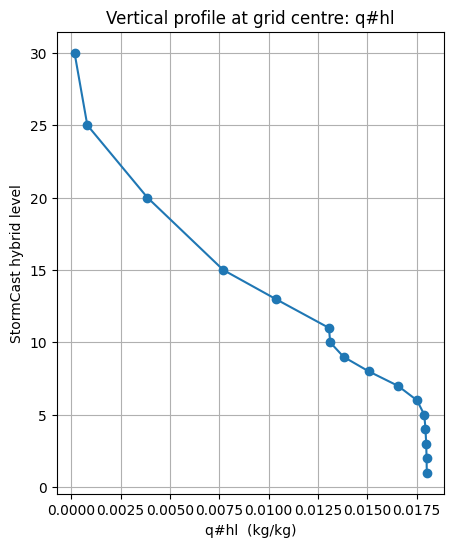

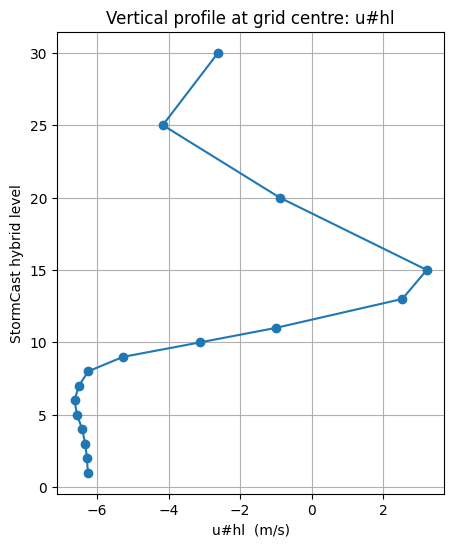

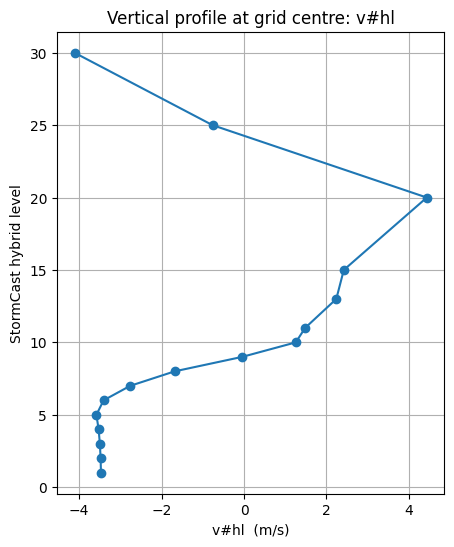

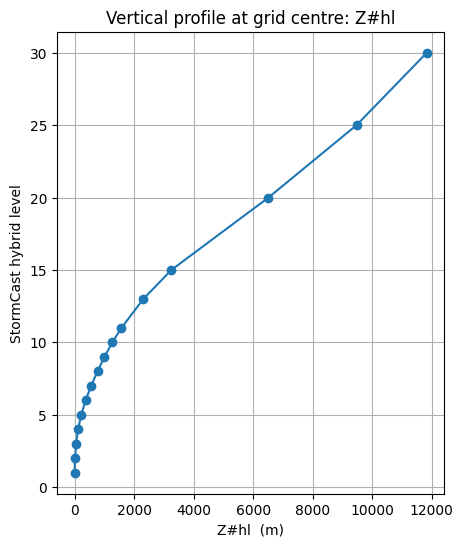

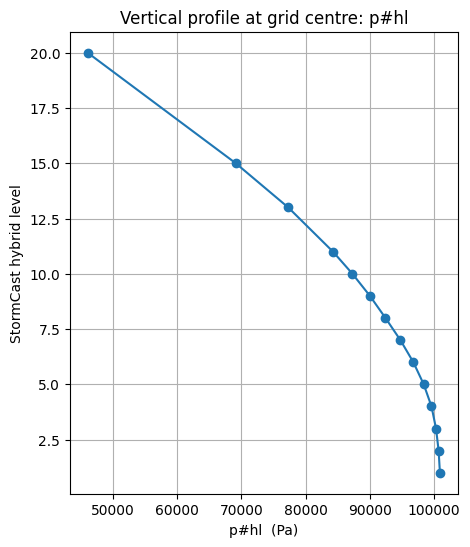

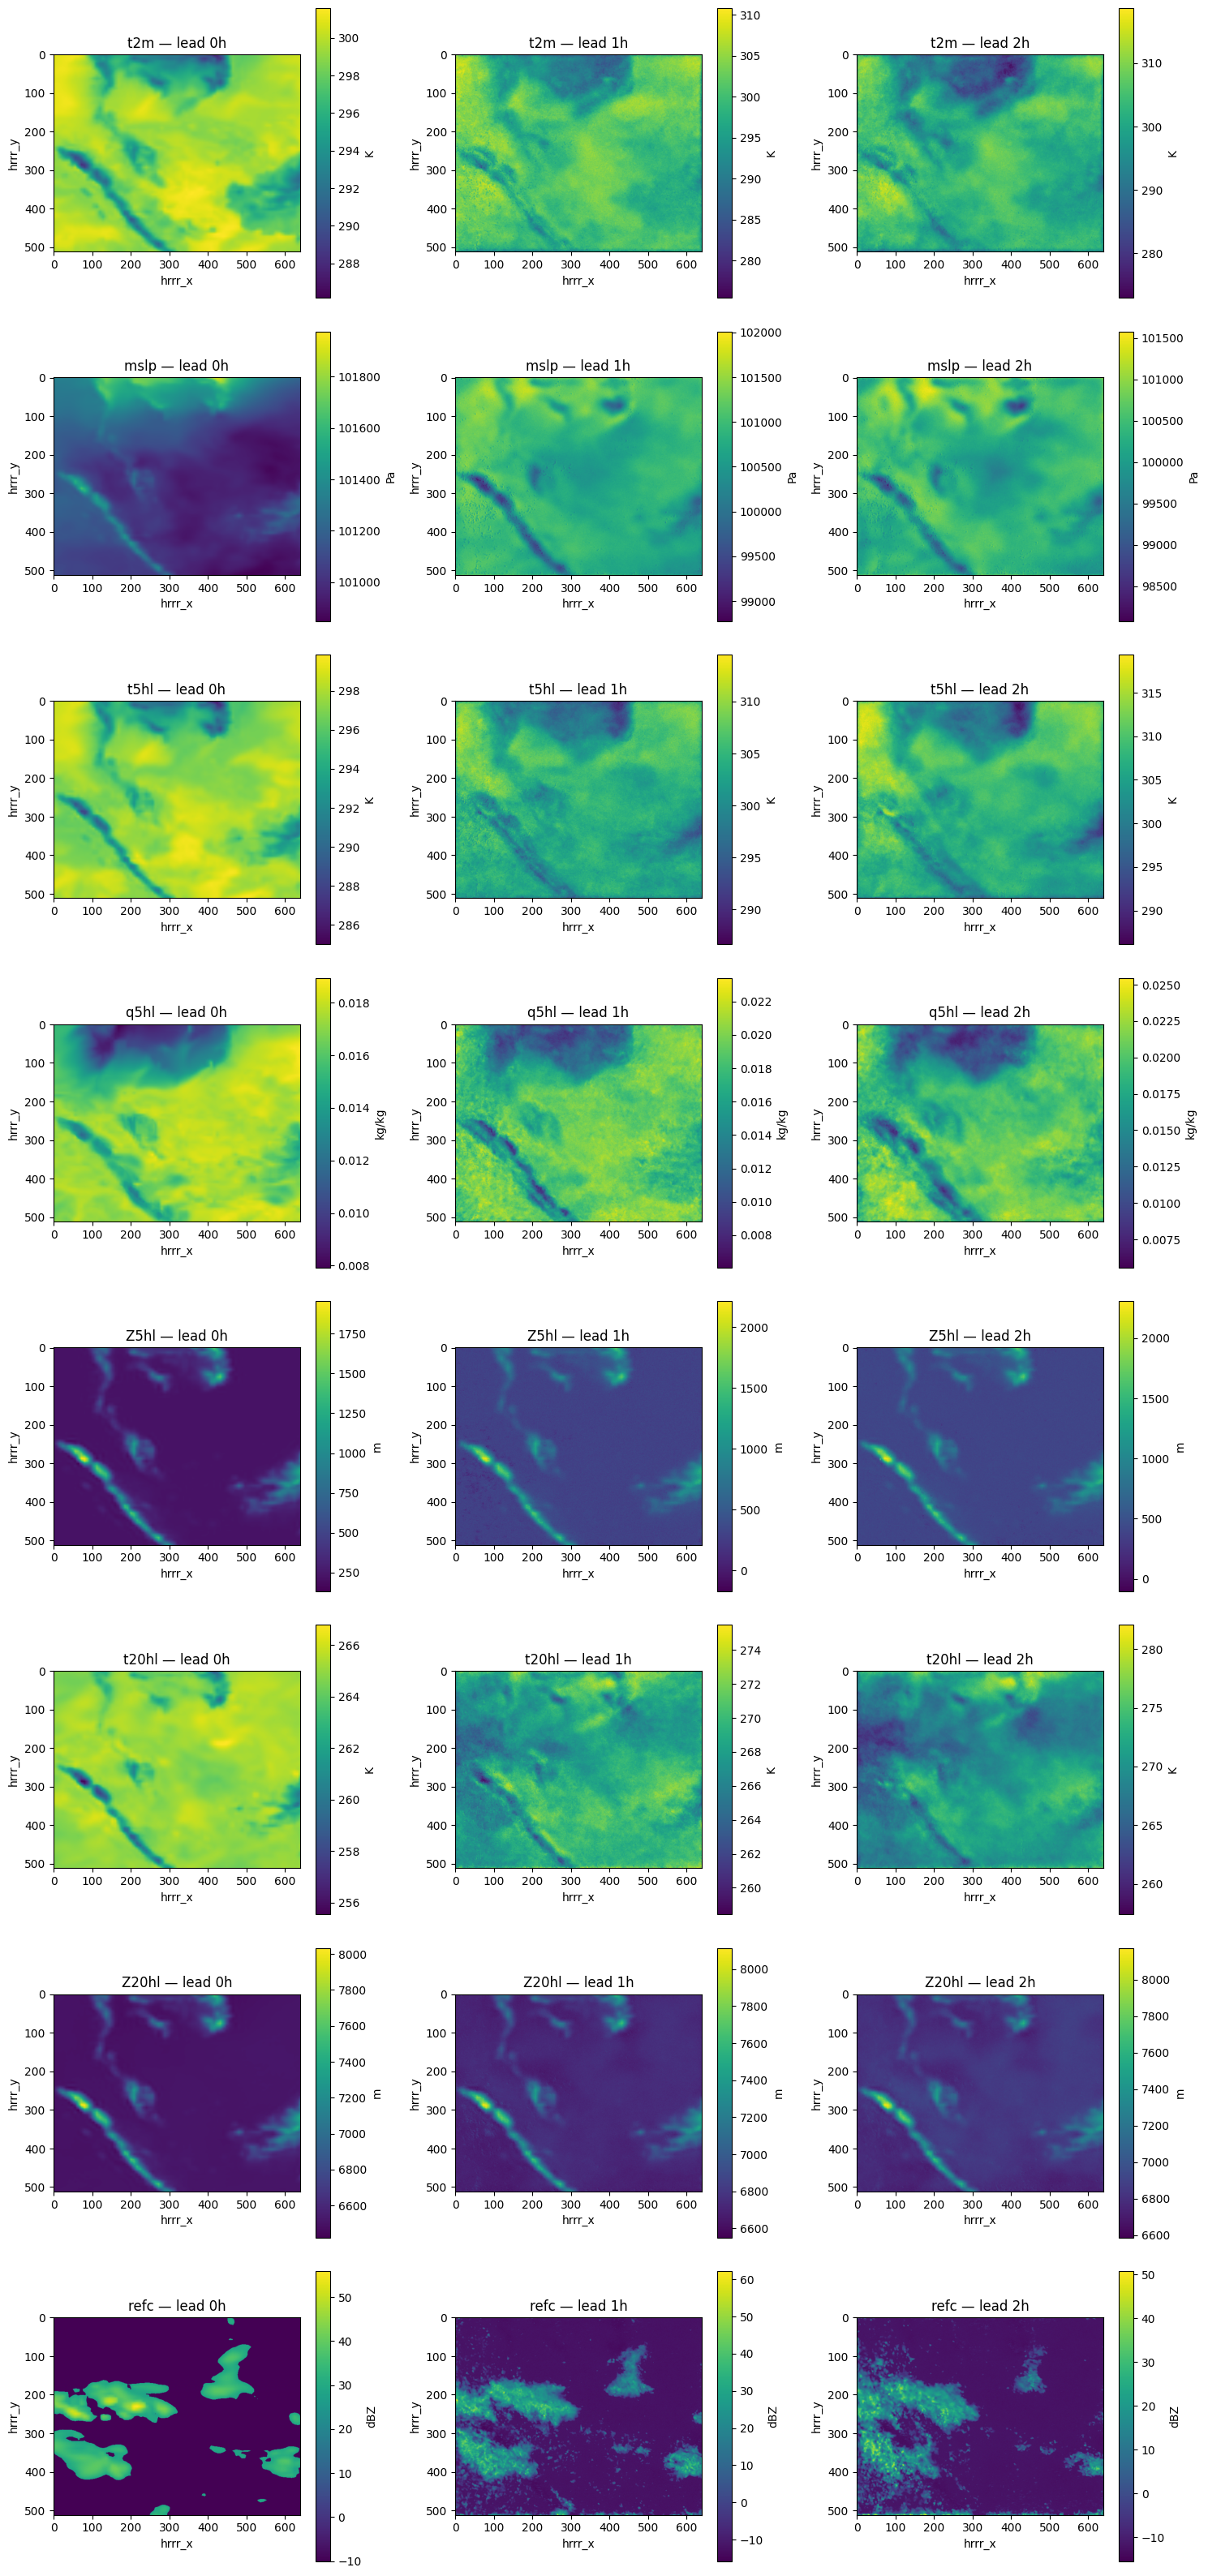

In [ ]:
# ── 8. Plots ──────────────────────────────────────────────────────────────────

# Input fields
INPUT_VARS = [
    "t2m", "u10m", "v10m", "mslp",
    "t5hl", "q5hl", "u5hl", "Z5hl", "p5hl",
    "t20hl", "q20hl", "u20hl", "Z20hl",
    "t30hl", "u30hl", "Z30hl", "refc",
]

ut.plot_fields(
    {
        v: data.sel(variable=v).isel(time=0).values
        for v in INPUT_VARS
    },
    title_prefix="Input: ",
)

ut.plot_vertical_profile(data)

# Output fields
ds_out = xr.open_zarr(PATH_OUTPUT)

OUTPUT_VARS = ["t2m", "mslp", "t5hl", "q5hl", "Z5hl", "t20hl", "Z20hl", "refc"]

n_leads = ds_out.sizes["lead_time"]
n_vars = len(OUTPUT_VARS)

fig, axes = plt.subplots(
    n_vars,
    n_leads,
    figsize=(5 * n_leads, 4 * n_vars),
    squeeze=False,
)

for row, var in enumerate(OUTPUT_VARS):
    for col in range(n_leads):
        field = ds_out[var].isel(time=0, lead_time=col).values

        im = axes[row, col].imshow(field, origin="upper")
        axes[row, col].set_title(f"{var} — lead {col}h")
        axes[row, col].set_xlabel("hrrr_x")
        axes[row, col].set_ylabel("hrrr_y")

        plt.colorbar(im, ax=axes[row, col], label=ut.infer_unit(var))

plt.tight_layout()
plt.show()

# Comparison

In [ ]:
truth0 = build_era5_truth(STARTING_TIME)

for var in ["t2m", "mslp", "u10m", "v10m", "t5hl", "q5hl", "Z5hl"]:
    truth_field = truth0.sel(variable=var).values
    forecast_field = ds_out[var].isel(time=0, lead_time=0).values

    error = forecast_field - truth_field
    rmse = np.sqrt(np.nanmean(error ** 2))

    print(f"lead 0 {var:5s} RMSE: {rmse:.6g} {ut.infer_unit(var)}")

lead 0 t2m   RMSE: 0 K
lead 0 mslp  RMSE: 0 Pa
lead 0 u10m  RMSE: 0 m/s
lead 0 v10m  RMSE: 0 m/s
lead 0 t5hl  RMSE: 0 K
lead 0 q5hl  RMSE: 0 kg/kg
lead 0 Z5hl  RMSE: 0 m
